<a href="https://colab.research.google.com/github/faheema2006/MLOPS/blob/main/SkillSync(Random_Forest).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
dataset = pd.read_csv('/content/clean_resume_dataset.csv')
print(dataset.head())

    ResumeID        Category              Name              Email  \
0  REAL_0001  Java Developer      Chad Griffin  contact@email.com   
1  REAL_0002  Java Developer    Melinda Thomas  contact@email.com   
2  REAL_0003  Java Developer  Shannon Mccarthy  contact@email.com   
3  REAL_0004  Java Developer  Christine Kelley  contact@email.com   
4  REAL_0005  Java Developer        Karen Holt  contact@email.com   

                                               Phone     Location  \
0  94105 555 4321000          10                 ...  City, State   
1  17994568777  2017 2018 20152016       3       ...  City, State   
2  9  555 4321000      94105   8                 ...  City, State   
3  9  555 4321000      94105   5                 ...  City, State   
4  100   10   4321000                            ...  City, State   

                                             Summary                   Skills  \
0  jessica claire montgomery street san francisco...  Python, SQL, Git, Linux   
1  jared

In [3]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [4]:
tfidf = TfidfVectorizer(max_features=300)

In [6]:
X = tfidf.fit_transform(dataset['Text']).toarray()

In [7]:
from sklearn.preprocessing import LabelEncoder

In [8]:
encoder = LabelEncoder()
y = encoder.fit_transform(dataset['Category'])

In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

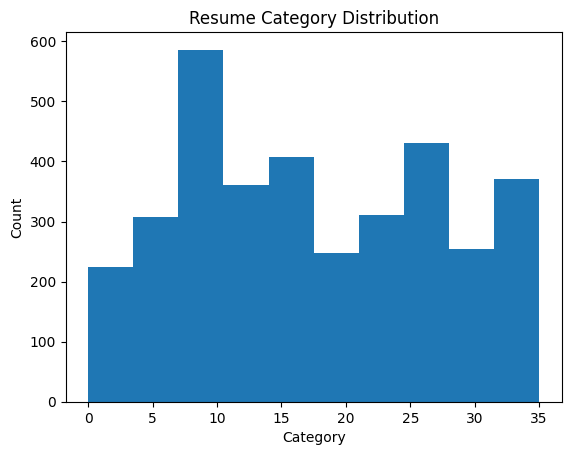

In [10]:
plt.hist(y)
plt.xlabel('Category')
plt.ylabel('Count')
plt.title('Resume Category Distribution')
plt.show()

In [11]:
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2)

In [13]:
from sklearn.ensemble import RandomForestClassifier

In [14]:
model = RandomForestClassifier(n_estimators=20)

In [15]:
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=20)

In [16]:
model.score(X_test, y_test)

0.8314285714285714

In [17]:
y_predicted = model.predict(X_test)

In [18]:
from sklearn.metrics import confusion_matrix

In [19]:
cm = confusion_matrix(y_test,y_predicted)

In [20]:
print(cm)

[[14  0  0 ...  0  0  0]
 [ 0 15  0 ...  0  0  0]
 [ 0  0  1 ...  0  0  0]
 ...
 [ 0  0  0 ... 29  0  0]
 [ 0  0  0 ...  0  8  0]
 [ 0  0  0 ...  1  0 16]]


In [21]:
import seaborn as sn

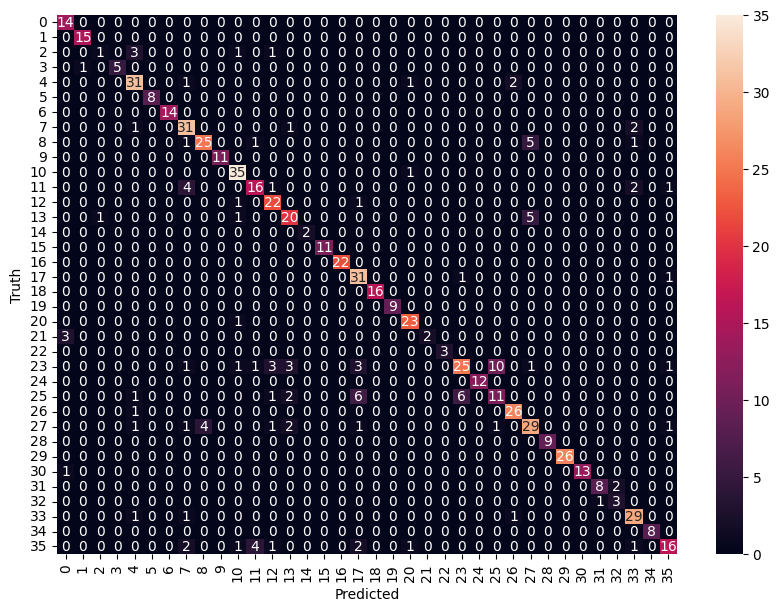

In [22]:
plt.figure(figsize=(10,7))
sn.heatmap(cm,annot=True)
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [23]:
sample_resume = ["""Python Machine Learning SQL Data Analysis Deep Learning"""]

In [24]:
sample_vector = tfidf.transform(sample_resume).toarray()

In [25]:
prediction = model.predict(sample_vector)

In [26]:
predicted_category = encoder.inverse_transform(prediction)
print(predicted_category)

['Data Science']
